In [3]:
import re
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_style("whitegrid")

DATA_DIR = Path("data/PStance")
TARGETS = ["trump", "biden", "bernie"]
SPLITS = ["train", "val", "test"]

In [4]:
def load_all(data_dir: Path) -> pd.DataFrame:
    frames = []
    for split in SPLITS:
        for target in TARGETS:
            f = data_dir / f"raw_{split}_{target}.csv"
            df = pd.read_csv(f)
            df["split"] = split
            df["target_file"] = target
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

df = load_all(DATA_DIR)
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head(3)


Total rows: 21,574
Columns: ['Tweet', 'Target', 'Stance', 'split', 'target_file']


,Tweet,Target,Stance,split,target_file
0,You COWARD... you should have been at THE WHITE HOUSE CORRESPONDENCE DINNER Honoring the FIRST AMENDMENT! #FirstAmen...,Donald Trump,AGAINST,train,trump
1,"Cool. I trust he requested the same records for don jr, ivanka, Eric and jarrod? #Trump",Donald Trump,AGAINST,train,trump
2,Off your meds again Donnie? You are surrounded by criminals of all sorts! We love California and our gov so F off! #...,Donald Trump,AGAINST,train,trump


In [5]:
print("Nulls per column:")
print(df.isna().sum(), "\n")

print("Stance label vocabulary:", df["Stance"].unique())
print("Target vocabulary    :", df["Target"].unique())

print(f"\nExact-duplicate tweets across whole corpus: {df.duplicated(subset='Tweet').sum()}")
print(f"Duplicate (Tweet, Target) pairs            : {df.duplicated(subset=['Tweet','Target']).sum()}")


Nulls per column:
Tweet          0
Target         0
Stance         0
split          0
target_file    0
dtype: int64 

Stance label vocabulary: <StringArray>
['AGAINST', 'FAVOR']
Length: 2, dtype: str
Target vocabulary    : <StringArray>
['Donald Trump', 'Joe Biden', 'Bernie Sanders']
Length: 3, dtype: str

Exact-duplicate tweets across whole corpus: 3
Duplicate (Tweet, Target) pairs            : 3


In [6]:
sizes = (
    df.groupby(["target_file", "split"])
      .size()
      .unstack("split")[SPLITS]
)
sizes["total"] = sizes.sum(axis=1)
sizes.loc["ALL"] = sizes.sum()
sizes


split,train,val,test,total
target_file,,,,
bernie,5056,634,635,6325
biden,5806,745,745,7296
trump,6362,814,777,7953
ALL,17224,2193,2157,21574


In [7]:
balance = (
    df.groupby(["target_file", "split", "Stance"])
      .size()
      .unstack("Stance")
      .fillna(0)
      .astype(int)
)
balance["%FAVOR"] = (balance["FAVOR"] / balance.sum(axis=1) * 100).round(1)
balance


Stance             AGAINST  FAVOR  %FAVOR
target_file split                        
bernie      test       292    343    54.0
            train     2198   2858    56.5
            val        284    350    55.2
biden       test       408    337    45.2
            train     3254   2552    44.0
            val        417    328    44.0
trump       test       425    352    45.3
            train     3425   2937    46.2
            val        440    374    45.9

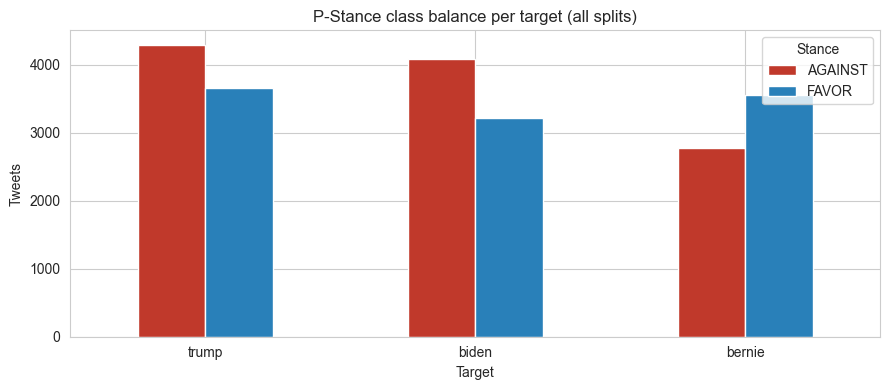

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = (
    df.groupby(["target_file", "Stance"])
      .size()
      .unstack("Stance")
      .reindex(TARGETS)
)
plot_df.plot(kind="bar", stacked=False, ax=ax, color=["#c0392b", "#2980b9"])
ax.set_title("P-Stance class balance per target (all splits)")
ax.set_ylabel("Tweets")
ax.set_xlabel("Target")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


            char_len                                                word_len  \
               count   mean   std   min    25%    50%    75%    max    count   
target_file                                                                    
bernie        6325.0  184.9  66.4  44.0  127.0  183.0  250.0  313.0   6325.0   
biden         7296.0  170.5  67.9  41.0  112.0  161.0  235.0  296.0   7296.0   
trump         7953.0  186.4  64.6  42.0  132.0  190.0  246.0  302.0   7953.0   

                                                       
             mean   std   min   25%   50%   75%   max  
target_file                                            
bernie       30.7  11.5   9.0  20.0  30.0  41.0  68.0  
biden        28.7  11.7   9.0  19.0  27.0  38.0  59.0  
trump        30.0  10.9  10.0  20.0  30.0  39.0  58.0  


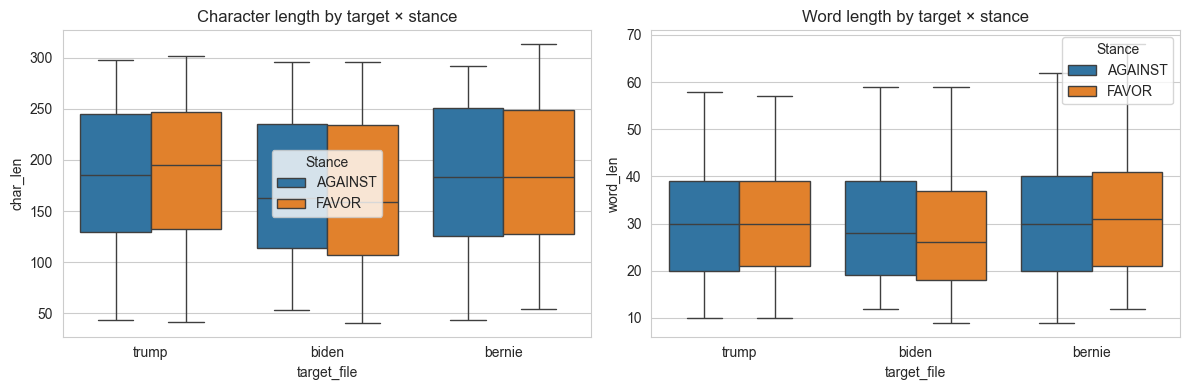

In [9]:
df["char_len"] = df["Tweet"].str.len()
df["word_len"] = df["Tweet"].str.split().str.len()

print(df.groupby("target_file")[["char_len", "word_len"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="target_file", y="char_len", hue="Stance", ax=axes[0])
axes[0].set_title("Character length by target × stance")
sns.boxplot(data=df, x="target_file", y="word_len", hue="Stance", ax=axes[1])
axes[1].set_title("Word length by target × stance")
plt.tight_layout()
plt.show()


In [10]:
URL_RE     = re.compile(r"https?://\S+|www\.\S+")
HASHTAG_RE = re.compile(r"#\w+")
MENTION_RE = re.compile(r"@\w+")
EMOJI_RE   = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF" "]", flags=re.UNICODE
)

df["n_hashtags"] = df["Tweet"].apply(lambda t: len(HASHTAG_RE.findall(t)))
df["n_mentions"] = df["Tweet"].apply(lambda t: len(MENTION_RE.findall(t)))
df["n_urls"]     = df["Tweet"].apply(lambda t: len(URL_RE.findall(t)))
df["n_emoji"]    = df["Tweet"].apply(lambda t: len(EMOJI_RE.findall(t)))

surface = df.groupby("target_file")[["n_hashtags","n_mentions","n_urls","n_emoji"]].mean().round(2)
print("Avg per tweet:")
print(surface)


Avg per tweet:
             n_hashtags  n_mentions  n_urls  n_emoji
target_file                                         
bernie             1.74        0.36     0.0      0.0
biden              1.45        0.65     0.0      0.0
trump              2.50        0.59     0.0      0.0


In [11]:
TARGET_TOKENS = {
    "trump":  [r"\btrump\b", r"#trump\b", r"@realdonaldtrump\b", r"\bdonald\b"],
    "biden":  [r"\bbiden\b", r"#biden\b", r"@joebiden\b", r"\bjoe\b"],
    "bernie": [r"\bbernie\b", r"#bernie\b", r"@berniesanders\b", r"\bsanders\b"],
}

def mentions_target(row):
    pats = TARGET_TOKENS[row["target_file"]]
    text = row["Tweet"].lower()
    return any(re.search(p, text) for p in pats)

df["mentions_target"] = df.apply(mentions_target, axis=1)

leak = (
    df.groupby(["target_file", "Stance"])["mentions_target"]
      .mean()
      .unstack("Stance")
      .round(3) * 100
)
print("% of tweets that contain the target name/handle/hashtag:")
print(leak)


% of tweets that contain the target name/handle/hashtag:
Stance       AGAINST  FAVOR
target_file                
bernie          73.2   70.4
biden           76.7   79.7
trump           85.5   90.9


In [12]:
def top_hashtags(group, n=10):
    tags = []
    for t in group["Tweet"]:
        tags.extend(h.lower() for h in HASHTAG_RE.findall(t))
    return pd.Series(Counter(tags).most_common(n))

for target in TARGETS:
    print(f"\n=== {target.upper()} ===")
    for stance in ["FAVOR", "AGAINST"]:
        sub = df[(df["target_file"] == target) & (df["Stance"] == stance)]
        top = Counter()
        for t in sub["Tweet"]:
            top.update(h.lower() for h in HASHTAG_RE.findall(t))
        print(f"  {stance:>7}: {top.most_common(8)}")



=== TRUMP ===
    FAVOR: [('#trump', 1547), ('#dems', 300), ('#maga', 281), ('#kag', 221), ('#donaldtrump', 196), ('#gop', 183), ('#democrat', 160), ('#president', 120)]
  AGAINST: [('#trump', 1957), ('#gop', 559), ('#donaldtrump', 386), ('#republican', 171), ('#coronavirus', 96), ('#president', 95), ('#dems', 92), ('#maga', 85)]

=== BIDEN ===
    FAVOR: [('#joebiden', 799), ('#biden', 663), ('#democraticdebate', 113), ('#election2020', 103), ('#demdebate', 73), ('#democrats', 46), ('#2020election', 45), ('#voteblue2020', 44)]
  AGAINST: [('#joebiden', 1097), ('#biden', 1039), ('#democraticdebate', 174), ('#demdebate', 103), ('#democrats', 68), ('#dems', 64), ('#ukraine', 63), ('#democrat', 60)]

=== BERNIE ===
    FAVOR: [('#berniesanders', 1239), ('#bernie', 1132), ('#medicareforall', 155), ('#notmeus', 149), ('#sanders', 140), ('#democraticdebate', 105), ('#demdebate', 81), ('#nomiddleground', 52)]
  AGAINST: [('#bernie', 960), ('#berniesanders', 921), ('#sanders', 198), ('#democr

In [13]:
def normalize(t: str) -> str:
    t = unicodedata.normalize("NFKC", t).lower()
    t = URL_RE.sub("", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["norm"] = df["Tweet"].apply(normalize)

leakage_rows = []
for target in TARGETS:
    sub = df[df["target_file"] == target]
    train_set = set(sub.loc[sub["split"] == "train", "norm"])
    val_set   = set(sub.loc[sub["split"] == "val",   "norm"])
    test_set  = set(sub.loc[sub["split"] == "test",  "norm"])
    leakage_rows.append({
        "target": target,
        "train∩val":  len(train_set & val_set),
        "train∩test": len(train_set & test_set),
        "val∩test":   len(val_set & test_set),
    })
pd.DataFrame(leakage_rows).set_index("target")


,train∩val,train∩test,val∩test
target,,,
trump,0,0,0
biden,0,0,1
bernie,0,1,0


In [14]:
from collections import defaultdict

TOKEN_RE = re.compile(r"[a-z][a-z']+")

def token_counts(texts):
    c = Counter()
    for t in texts:
        c.update(TOKEN_RE.findall(t.lower()))
    return c

def log_odds(c1, c2, alpha=1.0, top_n=15):
    vocab = set(c1) | set(c2)
    n1, n2 = sum(c1.values()), sum(c2.values())
    rows = []
    for w in vocab:
        a, b = c1[w] + alpha, c2[w] + alpha
        score = np.log(a / (n1 + alpha*len(vocab))) - np.log(b / (n2 + alpha*len(vocab)))
        rows.append((w, score, c1[w], c2[w]))
    out = pd.DataFrame(rows, columns=["token", "log_odds", "favor_n", "against_n"])
    return out

for target in TARGETS:
    sub = df[df["target_file"] == target]
    fav = token_counts(sub.loc[sub.Stance == "FAVOR",   "Tweet"])
    agn = token_counts(sub.loc[sub.Stance == "AGAINST", "Tweet"])
    lo  = log_odds(fav, agn)
    lo  = lo[(lo.favor_n + lo.against_n) >= 20]   # filter rare tokens
    print(f"\n=== {target.upper()} — most FAVOR-leaning tokens ===")
    print(lo.nlargest(10, "log_odds").to_string(index=False))
    print(f"=== {target.upper()} — most AGAINST-leaning tokens ===")
    print(lo.nsmallest(10, "log_odds").to_string(index=False))



=== TRUMP — most FAVOR-leaning tokens ===
            token  log_odds  favor_n  against_n
              wwg  4.164245       55          0
        socialist  3.665254       33          0
          votered  3.665254       33          0
        obamagate  3.471098       27          0
         patriots  3.453080      109          3
bestpresidentever  3.396990       25          0
         walkaway  3.265654      113          4
      wethepeople  3.229936       43          1
              wga  3.183416       41          1
     buildthewall  3.151155       60          2
=== TRUMP — most AGAINST-leaning tokens ===
        token  log_odds  favor_n  against_n
      fucking -2.694320        1         33
      impotus -2.426056        3         51
       orange -2.400080        2         37
         test -2.386835        1         24
  liarinchief -2.386835        1         24
  moscowmitch -2.129790        2         28
donaldtrump's -2.020591        2         25
        putin -1.911278       12 

In [15]:
target_vocab = {}
for target in TARGETS:
    sub = df[df["target_file"] == target]
    target_vocab[target] = set(token_counts(sub["Tweet"]).keys())

overlap = pd.DataFrame(index=TARGETS, columns=TARGETS, dtype=float)
for a in TARGETS:
    for b in TARGETS:
        inter = len(target_vocab[a] & target_vocab[b])
        union = len(target_vocab[a] | target_vocab[b])
        overlap.loc[a, b] = round(inter / union, 3)
print("Jaccard vocabulary overlap between targets:")
print(overlap)


Jaccard vocabulary overlap between targets:
        trump  biden  bernie
trump   1.000  0.326   0.313
biden   0.326  1.000   0.335
bernie  0.313  0.335   1.000


In [16]:
out_path = DATA_DIR / "pstance_unified.csv"
df.drop(columns=["norm"]).to_csv(out_path, index=False)
print(f"Wrote {len(df):,} rows → {out_path}")


Wrote 21,574 rows → data\PStance\pstance_unified.csv
